<a href="https://colab.research.google.com/github/td0309/Online-Retail-II/blob/main/retail.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import io
import re
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
with open('dataset_', 'r') as f:
    content = f.read()
print(f"Type of 'content': {type(content)}")
print(f"First 500 characters of 'content':\n{content[:500]}")

Type of 'content': <class 'str'>
First 500 characters of 'content':
% Context
% This Online Retail II data set contains all the transactions occurring for a UK-based and registered, non-store online retail between 01/12/2009 and 09/12/2011.The company mainly sells unique all-occasion gift-ware. Many customers of the company are wholesalers.
% Content
% Attribute Information:
% InvoiceNo: Invoice number. Nominal. A 6-digit integral number uniquely assigned to each transaction. If this code starts with the letter 'c', it indicates a cancellation.
% StockCode: Prod


In [ ]:
# Find the line where the actual data starts (after @DATA marker)
lines = content.split('\n')
skip_count = 0
for line in lines:
    skip_count += 1
    if line.strip() == '@DATA':
        break

# Load the data, skipping the header lines, using comma as a separator, no header, and specifying single quote as quotechar
df = pd.read_csv(io.StringIO(content), sep=',', skiprows=skip_count, header=None, quotechar="'")


In [ ]:
# Extract attribute names from the content
attribute_names = []
for line in content.split('\n'):
    if line.startswith('@ATTRIBUTE'):
        # Extract the name, which is the second word after @ATTRIBUTE
        match = re.match(r"@ATTRIBUTE\s+(\S+)", line)
        if match:
            attribute_names.append(match.group(1))

# Assign these names to the DataFrame columns
df.columns = attribute_names

display(df.head())

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer_ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7\"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


# Context
 This Online Retail II data set contains all the transactions occurring for a UK-based and registered, non-store online retail between 01/12/2009 and 09/12/2011.The company mainly sells unique all-occasion gift-ware. Many customers of the company are wholesalers.
# Content
Attribute Information:
- InvoiceNo: Invoice number. Nominal. A 6-digit integral number uniquely assigned to each transaction. If this code starts with the letter 'c', it indicates a cancellation.
- StockCode: Product (item) code. Nominal. A 5-digit integral number uniquely assigned to each distinct product.
- Description: Product (item) name. Nominal.
- Quantity: The quantities of each product (item) per transaction. Numeric.
- InvoiceDate: Invice date and time. Numeric. The day and time when a transaction was generated.
- UnitPrice: Unit price. Numeric. Product price per unit in sterling ().
- CustomerID: Customer number. Nominal. A 5-digit integral number uniquely assigned to each customer.
- Country: Country name. Nominal. The name of the country where a customer resides.


In [ ]:
df.describe()

,Quantity,Price
count,1.067371e+06,1.067371e+06
mean,9.938898e+00,4.649388e+00
std,1.727058e+02,1.235531e+02
min,-8.099500e+04,-5.359436e+04
25%,1.000000e+00,1.250000e+00
50%,3.000000e+00,2.100000e+00
75%,1.000000e+01,4.150000e+00
max,8.099500e+04,3.897000e+04


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1067371 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer_ID  1067371 non-null  object 
 7   Country      1067371 non-null  object 
dtypes: float64(1), int64(1), object(6)
memory usage: 65.1+ MB


In [ ]:
df.shape

(1067371, 8)

In [ ]:
# Check for missing values in each column
missing_values = df.isnull().sum()

# Display the count of missing values per column
print("Missing values per column:")
display(missing_values)

Missing values per column:


Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer_ID    0
Country        0
dtype: int64

In [ ]:
print("Checking for negative values in numerical columns:")
negative_values_found = False
for column in df.select_dtypes(include=['number']).columns:
    negative_count = (df[column] < 0).sum()
    if negative_count > 0:
        print(f"  Column '{column}' has {negative_count} negative value(s).")
        negative_values_found = True
if not negative_values_found:
    print("  No negative values found in numerical columns.")

Checking for negative values in numerical columns:
  Column 'Quantity' has 22950 negative value(s).
  Column 'Price' has 5 negative value(s).


In [ ]:
# Convert InvoiceNo into String to find c (Cancelled transacion)
df['Invoice'] = df['Invoice'].astype(str)

# Define which InvoiceNo is started with C
cancelled_mask = df['Invoice'].str.startswith('C')
cancelled_count = cancelled_mask.sum()
total_count = len(df)

print(f"All transactions: {total_count:,}")
print(f"Cancelled ones (Cancelled - 'C'): {cancelled_count:,}")
print(f"Ratio of cancelled: {cancelled_count / total_count * 100:.2f}%")

# 5 randoms cancelled transactions
print("\n5 random cancelled transactions:")
display(df[cancelled_mask].sample(5, random_state=42))

All transactions: 1,067,371
Cancelled ones (Cancelled - 'C'): 19,494
Ratio of cancelled: 1.83%

5 random cancelled transactions:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer_ID,Country
908262,C569955,23110,PARISIENNE KEY CABINET,2,2011-10-06 18:35:00,5.75,17644.0,United Kingdom
236032,C512272,22027,TEA PARTY BIRTHDAY CARD,12,2010-06-14 13:32:00,0.42,15031.0,United Kingdom
828392,C563483,22927,GREEN GIANT GARDEN THERMOMETER,1,2011-08-16 15:59:00,5.95,14175.0,United Kingdom
626165,C544828,84279B,CHERRY BLOSSOM DECORATIVE FLASK,1,2011-02-24 09:49:00,3.75,17147.0,United Kingdom
45469,C493440,21843,RETRO SPOT CAKE STAND,1,2010-01-04 13:30:00,9.95,12709.0,Germany


In [ ]:
# Filter rows where 'Quantity' or 'Price' is negative
negative_values_df = df[(df['Quantity'] < 0) | (df['Price'] < 0)]

# Display a random sample of 5 such rows
print("Random 5 rows with negative Quantity or Price:")
display(negative_values_df.sample(min(5, len(negative_values_df))))

Random 5 rows with negative Quantity or Price:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer_ID,Country
432163,C530710,79323P,PINK CHERRY LIGHTS,-1,2010-11-04 11:31:00,6.75,17362.0,United Kingdom
436986,531165,16015,?,-270,2010-11-05 14:28:00,0.00,?,United Kingdom
329701,C521552,20803,SMALL PINK GLASS SUNDAE DISH,-6,2010-09-06 16:12:00,1.65,17685.0,United Kingdom
909489,C570099,85099B,JUMBO BAG RED RETROSPOT,-4,2011-10-07 12:11:00,1.65,13798.0,United Kingdom
288561,C517469,22327,ROUND SNACK BOXES SET OF 4 SKULLS,-1,2010-07-29 11:53:00,2.55,14680.0,United Kingdom


In [ ]:
# Convert negative 'Quantity' and 'Price' values to positive using absolute value
df['Quantity'] = df['Quantity'].abs()
df['Price'] = df['Price'].abs()

print("Negative values in 'Quantity' and 'Price' columns have been converted to positive.")

# Re-check for negative values to confirm the change
print("\nRe-checking for negative values in numerical columns after conversion:")
negative_values_found_after_conversion = False
for column in df.select_dtypes(include=['number']).columns:
    negative_count = (df[column] < 0).sum()
    if negative_count > 0:
        print(f"  Column '{column}' has {negative_count} negative value(s).")
        negative_values_found_after_conversion = True
if not negative_values_found_after_conversion:
    print("  No negative values found in numerical columns.")

display(df.head())

Negative values in 'Quantity' and 'Price' columns have been converted to positive.

Re-checking for negative values in numerical columns after conversion:
  No negative values found in numerical columns.


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer_ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7\"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


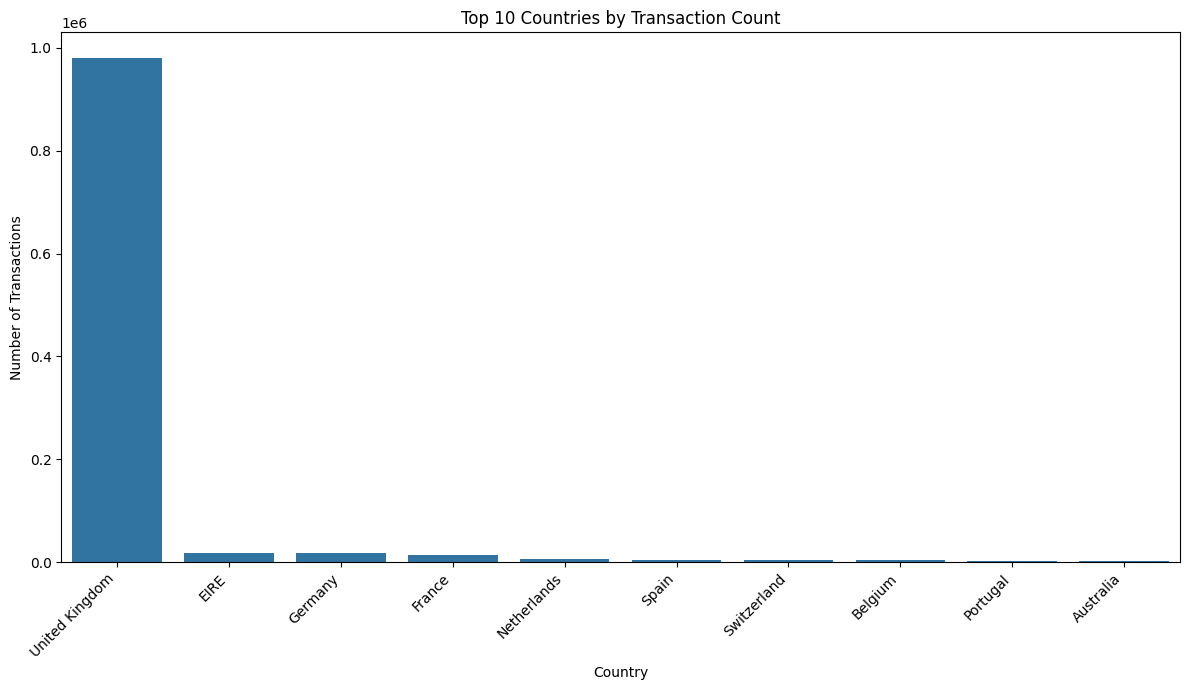

In [ ]:
plt.figure(figsize=(12, 7))
top_countries = df['Country'].value_counts().nlargest(10)
sns.barplot(x=top_countries.index, y=top_countries.values)
plt.title('Top 10 Countries by Transaction Count')
plt.xlabel('Country')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
print("\nTop 10 StockCodes:")
display(df['StockCode'].value_counts().nlargest(10))

print("\nTop 10 Descriptions:")
display(df['Description'].value_counts().nlargest(10))


Top 10 StockCodes:


StockCode
85123A    5829
22423     4424
85099B    4216
21212     3318
20725     3259
84879     2960
47566     2768
21232     2747
22197     2549
22383     2540
Name: count, dtype: int64


Top 10 Descriptions:


Description
WHITE HANGING HEART T-LIGHT HOLDER    5918
?                                     4474
REGENCY CAKESTAND 3 TIER              4412
JUMBO BAG RED RETROSPOT               3469
ASSORTED COLOUR BIRD ORNAMENT         2958
PARTY BUNTING                         2765
STRAWBERRY CERAMIC TRINKET BOX        2613
LUNCH BAG  BLACK SKULL.               2529
JUMBO STORAGE BAG SUKI                2434
HEART OF WICKER SMALL                 2319
Name: count, dtype: int64

In [ ]:
def find_and_display_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]

    print(f"\n--- Outliers for column: '{column}' ---")
    print(f"Q1 (25th percentile): {Q1:.2f}")
    print(f"Q3 (75th percentile): {Q3:.2f}")
    print(f"IQR: {IQR:.2f}")
    print(f"Lower Bound: {lower_bound:.2f}")
    print(f"Upper Bound: {upper_bound:.2f}")
    print(f"Total outliers found: {len(outliers)}")

    if not outliers.empty:
        print(f"Sample of {min(5, len(outliers))} outliers (first 5 rows):")
        display(outliers.head(5))
    else:
        print("No outliers found based on the IQR method.")

# Check for outliers in 'Quantity'
find_and_display_outliers_iqr(df, 'Quantity')

# Check for outliers in 'Price'
find_and_display_outliers_iqr(df, 'Price')


--- Outliers for column: 'Quantity' ---
Q1 (25th percentile): 1.00
Q3 (75th percentile): 10.00
IQR: 9.00
Lower Bound: -12.50
Upper Bound: 23.50
Total outliers found: 115571
Sample of 5 outliers (first 5 rows):


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer_ID,Country
3,489434,22041,"RECORD FRAME 7\"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.0,United Kingdom
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
10,489435,22195,HEART MEASURING SPOONS LARGE,24,2009-12-01 07:46:00,1.65,13085.0,United Kingdom



--- Outliers for column: 'Price' ---
Q1 (25th percentile): 1.25
Q3 (75th percentile): 4.15
IQR: 2.90
Lower Bound: -3.10
Upper Bound: 8.50
Total outliers found: 68105
Sample of 5 outliers (first 5 rows):


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer_ID,Country
35,489437,21360,JOY LARGE WOOD LETTERS,1,2009-12-01 09:08:00,9.95,15362.0,United Kingdom
38,489437,35400,WOODEN BOX ADVENT CALENDAR,2,2009-12-01 09:08:00,8.95,15362.0,United Kingdom
89,489439,POST,POSTAGE,3,2009-12-01 09:28:00,18.00,12682.0,France
126,489444,POST,POSTAGE,1,2009-12-01 09:55:00,141.00,12636.0,USA
131,489445,22180,RETRO SPOT LAMP,2,2009-12-01 09:57:00,9.95,17519.0,United Kingdom


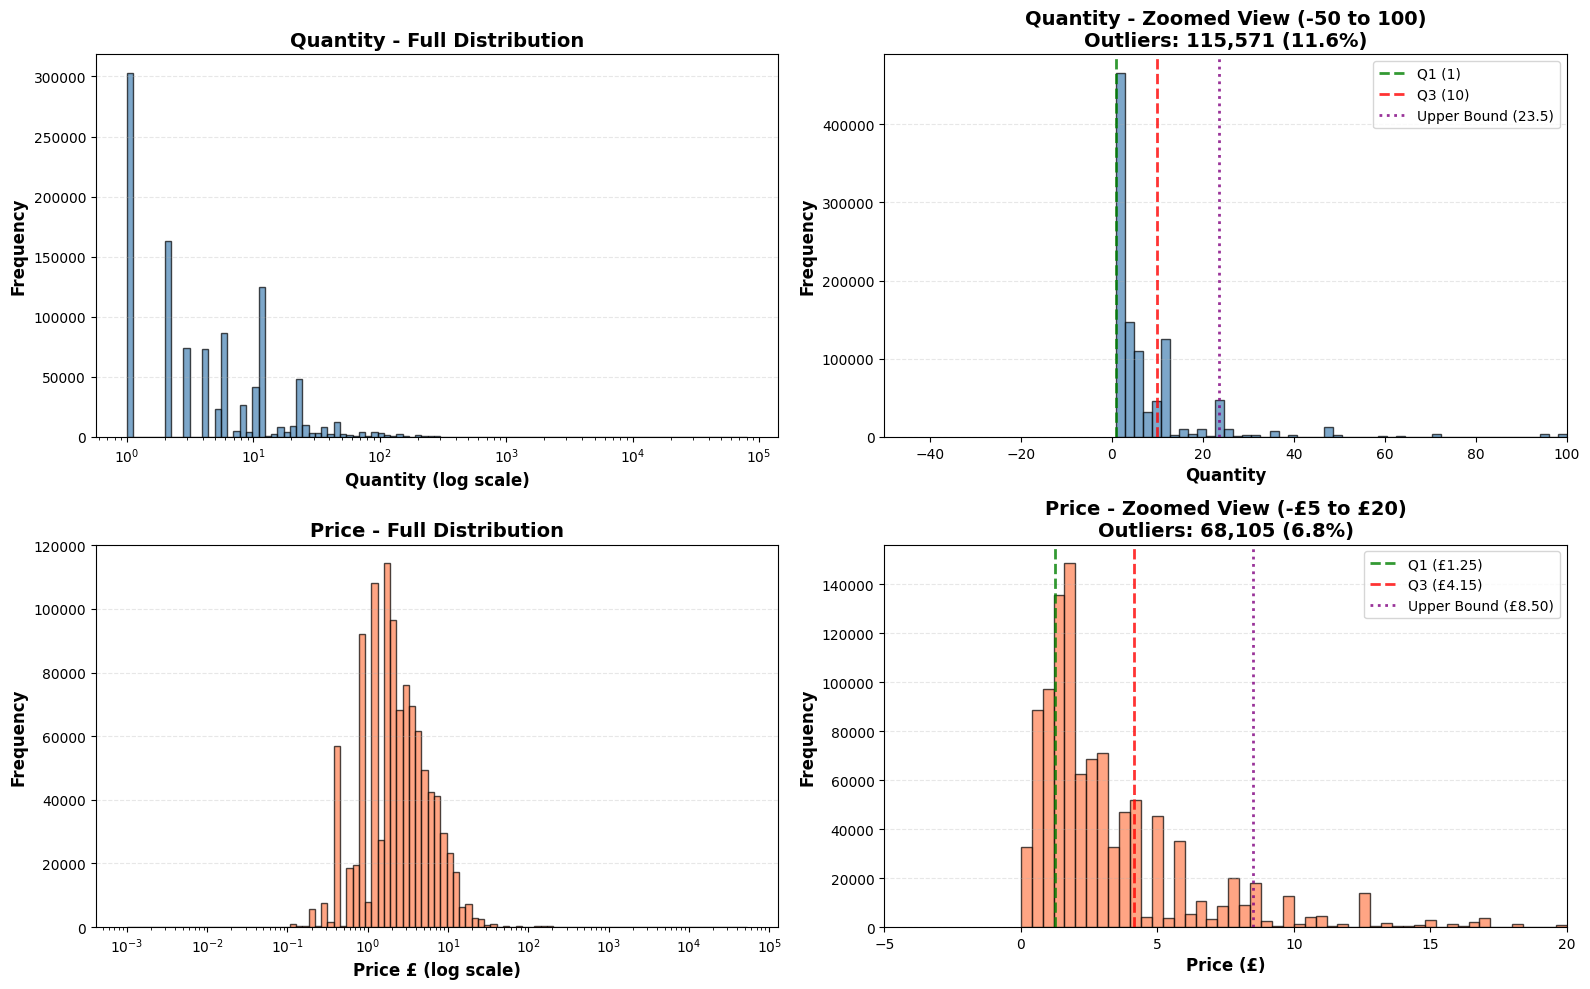


=== QUANTITY STATISTICS ===
Mean: 11.93
Median: 3.00
Std Dev: 172.58
Min: 1.00
Max: 80995.00

=== PRICE STATISTICS ===
Mean: £4.95
Median: £2.10
Std Dev: £123.54
Min: £0.00
Max: £53594.36


In [ ]:
# Create figure with 2x2 subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# === QUANTITY - Full Distribution (log-scale X to handle extreme outliers) ===
axes[0, 0].hist(df['Quantity'], bins=np.logspace(0, np.log10(df['Quantity'].max()), 100),
                 color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_xscale('log')
axes[0, 0].set_xlabel('Quantity (log scale)', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Frequency', fontsize=12, fontweight='bold')
axes[0, 0].set_title('Quantity - Full Distribution', fontsize=14, fontweight='bold')
axes[0, 0].grid(axis='y', alpha=0.3, linestyle='--')

# === QUANTITY - Zoomed (exclude extreme outliers) ===
# Focus on -50 to 100 range to see the main distribution
quantity_filtered = df[(df['Quantity'] >= -50) & (df['Quantity'] <= 100)]
axes[0, 1].hist(quantity_filtered['Quantity'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 1].axvline(x=1, color='green', linestyle='--', linewidth=2, label='Q1 (1)', alpha=0.8)
axes[0, 1].axvline(x=10, color='red', linestyle='--', linewidth=2, label='Q3 (10)', alpha=0.8)
axes[0, 1].axvline(x=23.5, color='purple', linestyle=':', linewidth=2, label='Upper Bound (23.5)', alpha=0.8)
axes[0, 1].set_xlabel('Quantity', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Frequency', fontsize=12, fontweight='bold')
axes[0, 1].set_title('Quantity - Zoomed View (-50 to 100)\nOutliers: 115,571 (11.6%)', fontsize=14, fontweight='bold')
axes[0, 1].legend(fontsize=10, loc='upper right')
axes[0, 1].grid(axis='y', alpha=0.3, linestyle='--')
axes[0, 1].set_xlim(-50, 100)

# === PRICE - Full Distribution (log-scale X to handle extreme outliers) ===
price_positive = df[df['Price'] > 0]['Price']  # log scale requires values > 0
axes[1, 0].hist(price_positive, bins=np.logspace(np.log10(price_positive.min()), np.log10(price_positive.max()), 100),
                 color='coral', edgecolor='black', alpha=0.7)
axes[1, 0].set_xscale('log')
axes[1, 0].set_xlabel('Price £ (log scale)', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Frequency', fontsize=12, fontweight='bold')
axes[1, 0].set_title('Price - Full Distribution', fontsize=14, fontweight='bold')
axes[1, 0].grid(axis='y', alpha=0.3, linestyle='--')

# === PRICE - Zoomed (exclude extreme outliers) ===
# Focus on -5 to 20 range to see the main distribution
price_filtered = df[(df['Price'] >= -5) & (df['Price'] <= 20)]
axes[1, 1].hist(price_filtered['Price'], bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[1, 1].axvline(x=1.25, color='green', linestyle='--', linewidth=2, label='Q1 (£1.25)', alpha=0.8)
axes[1, 1].axvline(x=4.15, color='red', linestyle='--', linewidth=2, label='Q3 (£4.15)', alpha=0.8)
axes[1, 1].axvline(x=8.50, color='purple', linestyle=':', linewidth=2, label='Upper Bound (£8.50)', alpha=0.8)
axes[1, 1].set_xlabel('Price (£)', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Frequency', fontsize=12, fontweight='bold')
axes[1, 1].set_title('Price - Zoomed View (-£5 to £20)\nOutliers: 68,105 (6.8%)', fontsize=14, fontweight='bold')
axes[1, 1].legend(fontsize=10, loc='upper right')
axes[1, 1].grid(axis='y', alpha=0.3, linestyle='--')
axes[1, 1].set_xlim(-5, 20)

plt.tight_layout()
plt.show()

# Optional: Print summary statistics
print("\n=== QUANTITY STATISTICS ===")
print(f"Mean: {df['Quantity'].mean():.2f}")
print(f"Median: {df['Quantity'].median():.2f}")
print(f"Std Dev: {df['Quantity'].std():.2f}")
print(f"Min: {df['Quantity'].min():.2f}")
print(f"Max: {df['Quantity'].max():.2f}")

print("\n=== PRICE STATISTICS ===")
print(f"Mean: £{df['Price'].mean():.2f}")
print(f"Median: £{df['Price'].median():.2f}")
print(f"Std Dev: £{df['Price'].std():.2f}")
print(f"Min: £{df['Price'].min():.2f}")
print(f"Max: £{df['Price'].max():.2f}")

In [ ]:
# Filter for UK transactions only
a = input("Choose a country: ")
print(a)
uk_data = df[df['Country'] == a]

print(f"Total {a} transactions: {len(uk_data):,}")
print(f"Percentage of total data: {len(uk_data)/len(df)*100:.1f}%")
print("\n" + "="*80)

# Group by product and count transactions
product_counts = uk_data.groupby(['StockCode', 'Description']).size().reset_index(name='TransactionCount')

# Sort by transaction count (most to least)
product_counts = product_counts.sort_values('TransactionCount', ascending=False)

# Calculate total quantity sold for each product
product_quantities = uk_data.groupby(['StockCode', 'Description'])['Quantity'].sum().reset_index(name='TotalQuantity')

# Merge the two dataframes
product_summary = product_counts.merge(product_quantities, on=['StockCode', 'Description'])

# Calculate percentage of total transactions
product_summary['% of Transactions'] = (product_summary['TransactionCount'] / len(uk_data) * 100).round(2)

print("\nTOP PRODUCTS PURCHASED IN THE ",a," (Most to Least)")
print("="*80)
print(f"{'Rank':<6} {'StockCode':<12} {'Description':<40} {'Transactions':<15} {'Total Qty':<12} {'%'}")
print("-"*80)

# Print top 50 products
for idx, row in product_summary.head(50).iterrows():
    rank = product_summary.index.get_loc(idx) + 1
    stock = str(row['StockCode'])[:10]
    desc = str(row['Description'])[:38]
    trans = f"{row['TransactionCount']:,}"
    qty = f"{int(row['TotalQuantity']):,}"
    pct = f"{row['% of Transactions']:.2f}%"

    print(f"{rank:<6} {stock:<12} {desc:<40} {trans:<15} {qty:<12} {pct}")



France
Total France transactions: 14,330
Percentage of total data: 1.3%


TOP PRODUCTS PURCHASED IN THE  France  (Most to Least)
Rank   StockCode    Description                              Transactions    Total Qty    %
--------------------------------------------------------------------------------
1      POST         POSTAGE                                  494             1,371        3.45%
2      21731        RED TOADSTOOL LED NIGHT LIGHT            139             2,797        0.97%
3      22326        ROUND SNACK BOXES SET OF4 WOODLAND       116             1,271        0.81%
4      22556        PLASTERS IN TIN CIRCUS PARADE            109             1,953        0.76%
5      22554        PLASTERS IN TIN WOODLAND ANIMALS         101             1,672        0.70%
6      22352        LUNCH BOX WITH CUTLERY RETROSPOT         99              894          0.69%
7      21086        SET/6 RED SPOTTY PAPER CUPS              88              2,154        0.61%
8      21559        STRAWB

CUSTOMER CHURN PREDICTION PIPELINE

Data after cleaning: 1,041,675 transactions
Unique customers: 5,879

Latest transaction date: 2011-12-09
Observation period cutoff: 2011-09-10

Transactions before cutoff: 837,759
Transactions in observation period: 203,916

FEATURE ENGINEERING

Total customers: 5,282
Churned customers: 2,989 (56.6%)
Active customers: 2,293 (43.4%)

Training set: 3,697 customers
Test set: 1,585 customers

MODEL TRAINING & EVALUATION

Training Logistic Regression...

Logistic Regression - TRAIN vs TEST PERFORMANCE
--------------------------------------------------------------------------------
Metric               Train           Test            Difference     
--------------------------------------------------------------------------------
Accuracy             0.7376          0.7432          -0.0056        
Precision            0.7487          0.7515          -0.0029        
Recall               0.8074          0.8161          -0.0087        
F1-Score             0.7

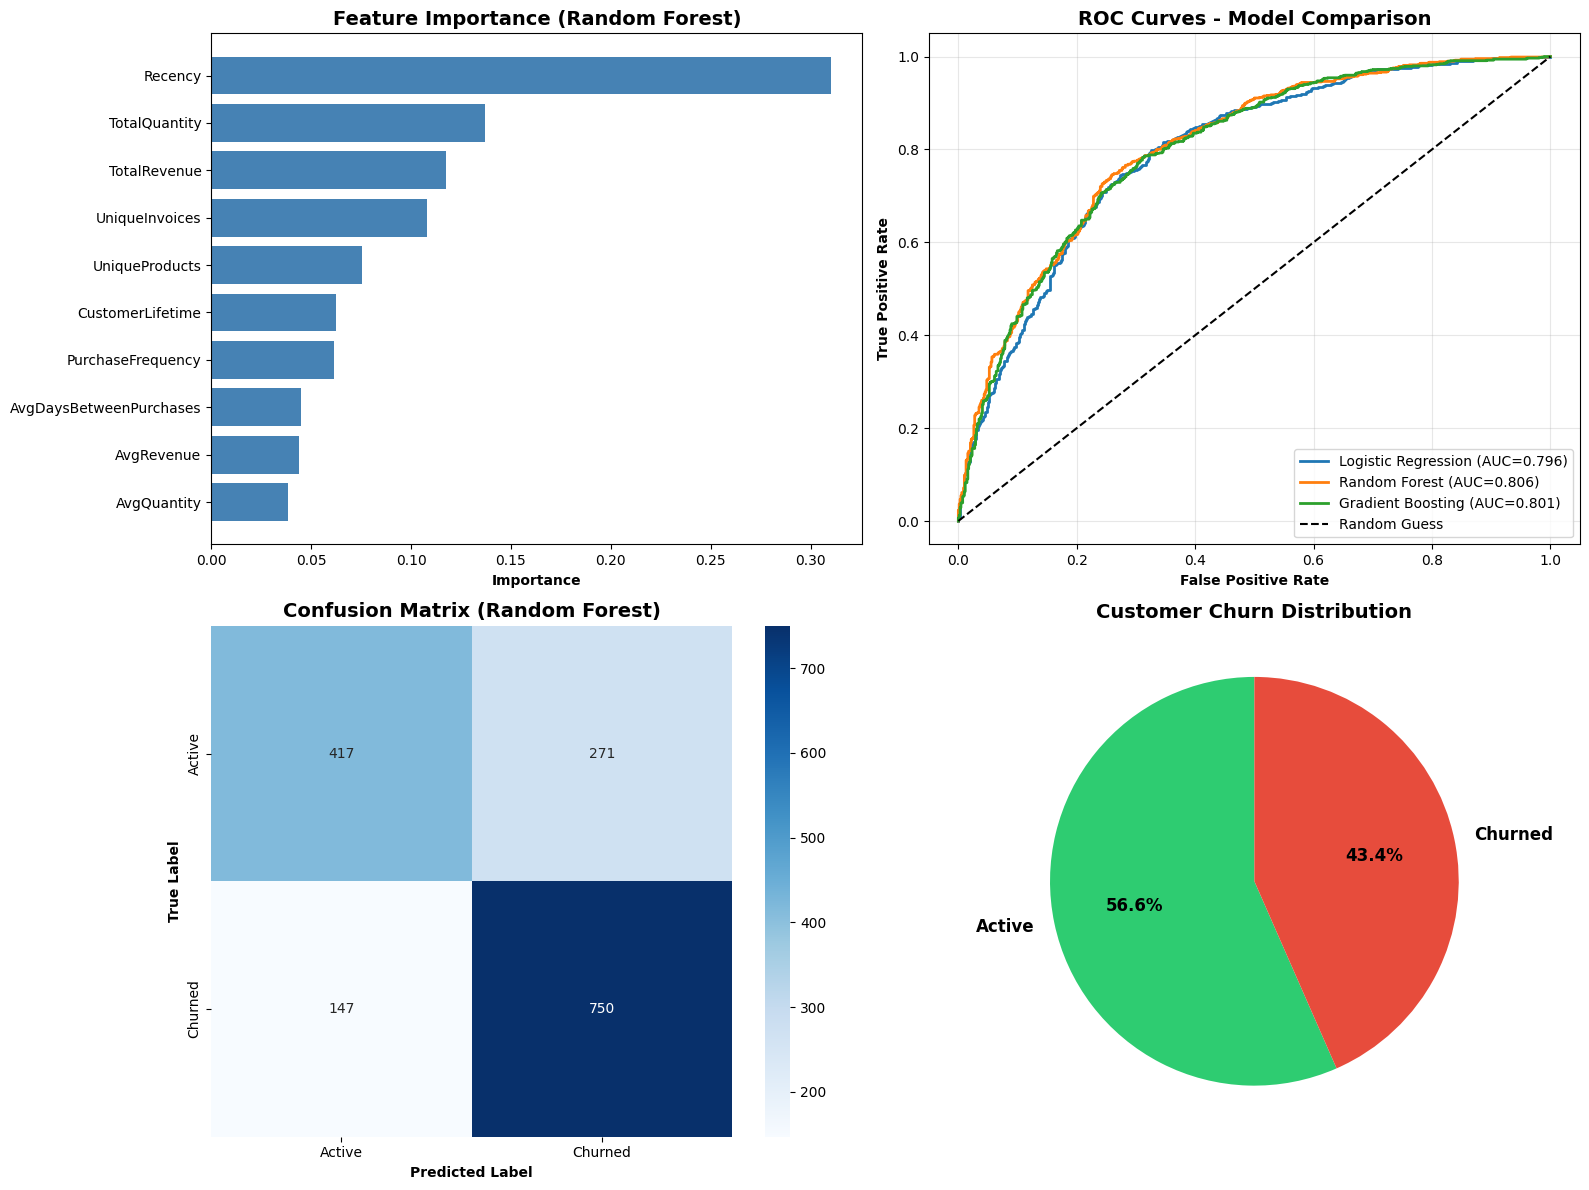


HIGH-RISK CUSTOMERS (Top 20 Most Likely to Churn)

Customer_ID     Churn Risk   Recency    Revenue      Invoices   Actually Churned
--------------------------------------------------------------------------------
14832.0               94.8%       539 £       323         1              Yes
12555.0               94.7%       591 £       129         1              Yes
15375.0               94.5%       599 £        61         1              Yes
16291.0               94.5%       591 £       118         1              Yes
13469.0               94.5%       562 £        82         1              Yes
12918.0               94.3%       535 £    10,954         1              Yes
12404.0               94.3%       591 £        63         1              Yes
12570.0               94.3%       591 £        78         1              Yes
18115.0               94.3%       607 £        10         1              Yes
15455.0               94.2%       507 £        38         1              Yes
16047.0         

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# STEP 1: DATA PREPARATION & FEATURE ENGINEERING
# ============================================================================

print("="*80)
print("CUSTOMER CHURN PREDICTION PIPELINE")
print("="*80)

# Convert InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Remove cancellations (invoices starting with 'C') for cleaner analysis
df_clean = df[~df['Invoice'].astype(str).str.startswith('C')].copy()

# Remove negative quantities and prices
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['Price'] > 0)]

# Calculate Revenue
df_clean['Revenue'] = df_clean['Quantity'] * df_clean['Price']

print(f"\nData after cleaning: {len(df_clean):,} transactions")
print(f"Unique customers: {df_clean['Customer_ID'].nunique():,}")

# ============================================================================
# STEP 2: DEFINE CHURN
# ============================================================================

# Get the latest date in the dataset
max_date = df_clean['InvoiceDate'].max()
print(f"\nLatest transaction date: {max_date.date()}")

# Define observation period: last 90 days
observation_cutoff = max_date - timedelta(days=90)
print(f"Observation period cutoff: {observation_cutoff.date()}")

# Customers who haven't purchased in last 90 days = CHURNED
# Split data: before cutoff = training features, after = churn label

# Calculate customer features from data BEFORE the cutoff
train_data = df_clean[df_clean['InvoiceDate'] < observation_cutoff].copy()
test_period = df_clean[df_clean['InvoiceDate'] >= observation_cutoff].copy()

print(f"\nTransactions before cutoff: {len(train_data):,}")
print(f"Transactions in observation period: {len(test_period):,}")

# ============================================================================
# STEP 3: CREATE CUSTOMER-LEVEL FEATURES (RFM + MORE)
# ============================================================================

print("\n" + "="*80)
print("FEATURE ENGINEERING")
print("="*80)

# Group by customer
customer_features = train_data.groupby('Customer_ID').agg({
    'InvoiceDate': ['max', 'min', 'count'],  # Recency, First purchase, Frequency
    'Invoice': 'nunique',  # Number of unique invoices
    'Revenue': ['sum', 'mean', 'std'],  # Monetary metrics
    'Quantity': ['sum', 'mean'],  # Purchase quantity
    'StockCode': 'nunique'  # Product diversity
}).reset_index()

# Flatten column names
customer_features.columns = ['Customer_ID', 'LastPurchaseDate', 'FirstPurchaseDate',
                             'TotalTransactions', 'UniqueInvoices', 'TotalRevenue',
                             'AvgRevenue', 'StdRevenue', 'TotalQuantity',
                             'AvgQuantity', 'UniqueProducts']

# Calculate Recency (days since last purchase before cutoff)
customer_features['Recency'] = (observation_cutoff - customer_features['LastPurchaseDate']).dt.days

# Calculate customer lifetime (days between first and last purchase)
customer_features['CustomerLifetime'] = (customer_features['LastPurchaseDate'] -
                                         customer_features['FirstPurchaseDate']).dt.days

# Purchase frequency (purchases per day active)
customer_features['PurchaseFrequency'] = customer_features['UniqueInvoices'] / (customer_features['CustomerLifetime'] + 1)

# Average days between purchases
customer_features['AvgDaysBetweenPurchases'] = customer_features['CustomerLifetime'] / (customer_features['UniqueInvoices'] + 1)

# Handle NaN in StdRevenue (customers with only 1 purchase)
customer_features['StdRevenue'].fillna(0, inplace=True)

# ============================================================================
# STEP 4: LABEL CUSTOMERS (CHURNED OR NOT)
# ============================================================================

# Customers who purchased in the observation period = NOT CHURNED
active_customers = test_period['Customer_ID'].unique()

# Create churn label: 1 = Churned, 0 = Active
customer_features['Churned'] = (~customer_features['Customer_ID'].isin(active_customers)).astype(int)

print(f"\nTotal customers: {len(customer_features):,}")
print(f"Churned customers: {customer_features['Churned'].sum():,} ({customer_features['Churned'].mean()*100:.1f}%)")
print(f"Active customers: {(1-customer_features['Churned']).sum():,} ({(1-customer_features['Churned'].mean())*100:.1f}%)")

# ============================================================================
# STEP 5: PREPARE DATA FOR MODELING
# ============================================================================

# Select features for modeling
feature_cols = ['Recency', 'TotalRevenue', 'AvgRevenue', 'UniqueInvoices',
                'TotalQuantity', 'AvgQuantity', 'UniqueProducts',
                'CustomerLifetime', 'PurchaseFrequency', 'AvgDaysBetweenPurchases']

X = customer_features[feature_cols]
y = customer_features['Churned']

# Handle any remaining NaN or inf values
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(0)

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nTraining set: {len(X_train):,} customers")
print(f"Test set: {len(X_test):,} customers")

# ============================================================================
# STEP 6: TRAIN MULTIPLE MODELS
# ============================================================================

print("\n" + "="*80)
print("MODEL TRAINING & EVALUATION")
print("="*80)

models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, max_depth=7),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    print(f"\n{'='*80}")
    print(f"Training {name}...")

    # Train model
    model.fit(X_train_scaled, y_train)

    # TRAIN SET PREDICTIONS
    y_train_pred = model.predict(X_train_scaled)
    y_train_pred_proba = model.predict_proba(X_train_scaled)[:, 1]

    # TEST SET PREDICTIONS
    y_test_pred = model.predict(X_test_scaled)
    y_test_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

    # Calculate metrics for TRAIN
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

    train_accuracy = accuracy_score(y_train, y_train_pred)
    train_precision = precision_score(y_train, y_train_pred)
    train_recall = recall_score(y_train, y_train_pred)
    train_f1 = f1_score(y_train, y_train_pred)
    train_roc_auc = roc_auc_score(y_train, y_train_pred_proba)

    # Calculate metrics for TEST
    test_accuracy = accuracy_score(y_test, y_test_pred)
    test_precision = precision_score(y_test, y_test_pred)
    test_recall = recall_score(y_test, y_test_pred)
    test_f1 = f1_score(y_test, y_test_pred)
    test_roc_auc = roc_auc_score(y_test, y_test_pred_proba)

    # Print results in table format
    print(f"\n{name} - TRAIN vs TEST PERFORMANCE")
    print("-" * 80)
    print(f"{'Metric':<20} {'Train':<15} {'Test':<15} {'Difference':<15}")
    print("-" * 80)
    print(f"{'Accuracy':<20} {train_accuracy:<15.4f} {test_accuracy:<15.4f} {train_accuracy - test_accuracy:<15.4f}")
    print(f"{'Precision':<20} {train_precision:<15.4f} {test_precision:<15.4f} {train_precision - test_precision:<15.4f}")
    print(f"{'Recall':<20} {train_recall:<15.4f} {test_recall:<15.4f} {train_recall - test_recall:<15.4f}")
    print(f"{'F1-Score':<20} {train_f1:<15.4f} {test_f1:<15.4f} {train_f1 - test_f1:<15.4f}")
    print(f"{'ROC-AUC':<20} {train_roc_auc:<15.4f} {test_roc_auc:<15.4f} {train_roc_auc - test_roc_auc:<15.4f}")
    print("-" * 80)

    # Check for overfitting
    if train_accuracy - test_accuracy > 0.1:
        print("⚠️  WARNING: Possible overfitting detected (train accuracy >> test accuracy)")
    elif test_accuracy > train_accuracy:
        print("✓ Model generalizes well to test data")
    else:
        print("✓ Model performance is consistent")

    # Store results
    results[name] = {
        'model': model,
        'y_pred': y_test_pred,
        'y_pred_proba': y_test_pred_proba,
        'roc_auc': test_roc_auc,
        'train_metrics': {
            'accuracy': train_accuracy,
            'precision': train_precision,
            'recall': train_recall,
            'f1': train_f1,
            'roc_auc': train_roc_auc
        },
        'test_metrics': {
            'accuracy': test_accuracy,
            'precision': test_precision,
            'recall': test_recall,
            'f1': test_f1,
            'roc_auc': test_roc_auc
        }
    }

# Print comparison summary
print("\n" + "="*80)
print("MODEL COMPARISON SUMMARY")
print("="*80)
print(f"{'Model':<25} {'Train Acc':<12} {'Test Acc':<12} {'Train F1':<12} {'Test F1':<12} {'Test ROC-AUC':<12}")
print("-" * 80)
for name, result in results.items():
    print(f"{name:<25} {result['train_metrics']['accuracy']:<12.4f} {result['test_metrics']['accuracy']:<12.4f} "
          f"{result['train_metrics']['f1']:<12.4f} {result['test_metrics']['f1']:<12.4f} {result['test_metrics']['roc_auc']:<12.4f}")

# ============================================================================
# STEP 7: VISUALIZATIONS
# ============================================================================

print("\n" + "="*80)
print("GENERATING VISUALIZATIONS")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Feature Importance (Random Forest)
rf_model = results['Random Forest']['model']
feature_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

axes[0, 0].barh(feature_importance['Feature'], feature_importance['Importance'], color='steelblue')
axes[0, 0].set_xlabel('Importance', fontweight='bold')
axes[0, 0].set_title('Feature Importance (Random Forest)', fontweight='bold', fontsize=14)
axes[0, 0].invert_yaxis()

# 2. ROC Curves
for name, result in results.items():
    fpr, tpr, _ = roc_curve(y_test, result['y_pred_proba'])
    axes[0, 1].plot(fpr, tpr, label=f"{name} (AUC={result['roc_auc']:.3f})", linewidth=2)

axes[0, 1].plot([0, 1], [0, 1], 'k--', label='Random Guess')
axes[0, 1].set_xlabel('False Positive Rate', fontweight='bold')
axes[0, 1].set_ylabel('True Positive Rate', fontweight='bold')
axes[0, 1].set_title('ROC Curves - Model Comparison', fontweight='bold', fontsize=14)
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# 3. Confusion Matrix (Best Model - Random Forest)
cm = confusion_matrix(y_test, results['Random Forest']['y_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1, 0],
            xticklabels=['Active', 'Churned'], yticklabels=['Active', 'Churned'])
axes[1, 0].set_ylabel('True Label', fontweight='bold')
axes[1, 0].set_xlabel('Predicted Label', fontweight='bold')
axes[1, 0].set_title('Confusion Matrix (Random Forest)', fontweight='bold', fontsize=14)

# 4. Churn Distribution
churn_dist = customer_features['Churned'].value_counts()
colors = ['#2ecc71', '#e74c3c']
axes[1, 1].pie(churn_dist.values, labels=['Active', 'Churned'], autopct='%1.1f%%',
               colors=colors, startangle=90, textprops={'fontsize': 12, 'fontweight': 'bold'})
axes[1, 1].set_title('Customer Churn Distribution', fontweight='bold', fontsize=14)

plt.tight_layout()
plt.show()

# ============================================================================
# STEP 8: HIGH-RISK CUSTOMERS
# ============================================================================

print("\n" + "="*80)
print("HIGH-RISK CUSTOMERS (Top 20 Most Likely to Churn)")
print("="*80)

# Get churn probabilities for all customers
best_model = results['Random Forest']['model']
customer_features_scaled = scaler.transform(customer_features[feature_cols].fillna(0))
customer_features['ChurnProbability'] = best_model.predict_proba(customer_features_scaled)[:, 1]

# Get high-risk customers
high_risk = customer_features.nlargest(20, 'ChurnProbability')[
    ['Customer_ID', 'ChurnProbability', 'Recency', 'TotalRevenue', 'UniqueInvoices', 'Churned']
]

print(f"\n{'Customer_ID':<15} {'Churn Risk':<12} {'Recency':<10} {'Revenue':<12} {'Invoices':<10} {'Actually Churned'}")
print("-"*80)
for _, row in high_risk.iterrows():
    print(f"{row['Customer_ID']:<15} {row['ChurnProbability']*100:>10.1f}% {row['Recency']:>9.0f} £{row['TotalRevenue']:>10,.0f} {row['UniqueInvoices']:>9.0f} {'Yes' if row['Churned']==1 else 'No':>16}")

print("\n" + "="*80)
print("PIPELINE COMPLETE!")
print("="*80)

*Recencey đơn vị không phải Bảng Anh mà là ngày, do sai sót trong code*

***Ưu điểm***

AUC ~0.80 cho cả 3 model (Random Forest cao nhất 0.806) — mức khá tốt cho bài toán churn, các đường ROC bám sát nhau nên model ổn định, không có model nào lệch bất thường.

Recency chiếm importance áp đảo (~0.31) — hợp lý về mặt logic nghiệp vụ, đúng bản chất bài toán churn.

Top 20 khách "high-risk" đều thực sự đã churn (cột "Actually Churned" toàn "Yes") — cho thấy model bắt đúng nhóm rủi ro cao nhất.

Recall của lớp Churned khá cao: 750/(750+147) ≈ 83.6% — bắt được phần lớn khách sắp rời bỏ, đây là điều quan trọng nhất trong bài toán churn (thà báo động nhầm còn hơn bỏ sót).

***Nhược điểm***

Feature importance đáng ngờ: Recency importance quá cao (0.31) trong khi cách định nghĩa churn label lại chính là "không mua trong 90 ngày" — tức là Recency gần như rò rỉ trực tiếp label (data leakage kiểu vòng lặp nhân quả: Recency cao → gần như chắc chắn churned). Đây không hẳn là mô hình học được hành vi khách hàng thực sự, mà một phần đang học lại chính định nghĩa churn.

False Positive cao: 271 khách Active bị dự đoán nhầm là Churned (precision lớp Churned chỉ ≈ 750/(750+271) ≈ 73.5%) — nếu dùng để chạy campaign giữ chân khách, sẽ tốn nguồn lực nhắm nhầm gần 1/4 khách vẫn đang active.

Churn rate 56.6% quá cao — hơn nửa khách hàng "churned" chỉ vì công thức 90 ngày cứng nhắc, không tính đến đặc thù ngành bán buôn/gift-ware (khách có thể mua theo mùa, không mua thường xuyên nhưng vẫn trung thành). Định nghĩa churn này có thể không phản ánh đúng thực tế kinh doanh.

Nhiều khách "high-risk" trong bảng top 20 chỉ có 1 invoice duy nhất — đây có thể là khách hàng mới/one-time buyer chứ không phải khách "rời bỏ" theo nghĩa thông thường, model đang gộp chung 2 nhóm khác nhau.